# CNN Evaluation — Tubes2 IF3270

Notebook ini mencakup:
1. **From-scratch vs Keras** — bandingkan prediksi pada test set
2. **Shared vs Non-Shared (LocallyConnected2D)**
3. **Analisis pengaruh hyperparameter** (layer, filter, kernel size, pooling)
4. **Grafik training/validation loss** per variasi

In [5]:
import os
base = '/kaggle/input/datasets/fudhailfayyadh0'
for d in os.listdir(base):
    print(d)
    files = os.listdir(os.path.join(base, d, 'data/weights'))
    print(files[:3])

datasetlokal2
['cnn_nL2_f32_64_k5_pAvg.keras', 'cnn_nL4_f32_64_k3_pAvg.h5', 'cnn_nL2_f32_64_k3_pAvg.keras']


In [6]:
import os, sys, json, glob, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as kl
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

BASE = '/kaggle/input/datasets/fudhailfayyadh0/datasetlokal2/src'
sys.path.insert(0, BASE)

from cnn.utils import load_image, load_batch
from cnn.layers import (
    Conv2DLayer, LocallyConnected2DLayer,
    MaxPooling2DLayer, AveragePooling2DLayer,
    GlobalAveragePooling2DLayer, FlattenLayer, DenseLayer,
)
from cnn.model import CNNFromScratch

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
class LocallyConnected2D(keras.layers.Layer):
    def __init__(self, filters, kernel_size, strides=(1, 1),
                 activation=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, (list, tuple)) else (kernel_size, kernel_size)
        self.strides = strides if isinstance(strides, (list, tuple)) else (strides, strides)
        self.activation = keras.activations.get(activation)
        self.use_bias = use_bias

    def build(self, input_shape):
        _, H, W, C_in = input_shape
        kH, kW = self.kernel_size
        sH, sW = self.strides
        self.out_H = (H - kH) // sH + 1
        self.out_W = (W - kW) // sW + 1
        num_positions = self.out_H * self.out_W
        flat_in = kH * kW * int(C_in)

        self.kernel_lc = self.add_weight(
            name='kernel',
            shape=(num_positions, flat_in, self.filters),
            initializer='glorot_uniform',
        )
        if self.use_bias:
            self.bias_lc = self.add_weight(
                name='bias',
                shape=(num_positions, self.filters),
                initializer='zeros',
            )
        else:
            self.bias_lc = None

    def call(self, x):
        kH, kW = self.kernel_size
        sH, sW = self.strides
        N = tf.shape(x)[0]

        patches = tf.image.extract_patches(
            images=x,
            sizes=[1, kH, kW, 1],
            strides=[1, sH, sW, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patches_flat = tf.reshape(patches, [N, self.out_H * self.out_W, -1])
        out = tf.einsum('npi,pio->npo', patches_flat, self.kernel_lc)
        if self.use_bias:
            out = out + self.bias_lc
        out = tf.reshape(out, [N, self.out_H, self.out_W, self.filters])
        return self.activation(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'strides': self.strides,
            'activation': keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
        })
        return cfg

## 0. Konfigurasi Path & Dataset

In [8]:
WEIGHTS_DIR = '/kaggle/input/datasets/fudhailfayyadh0/datasetlokal2/data/weights'
HISTORY_DIR = '/kaggle/input/datasets/fudhailfayyadh0/datasetlokal2/data/histories'
DATA_DIR    = '/kaggle/input/datasets/puneet6060/intel-image-classification'

IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

SPLIT_MAP = {
    'train': 'seg_train/seg_train',
    'test':  'seg_test/seg_test',
    'val':   'seg_test/seg_test',
}

CLASSES = sorted(os.listdir(os.path.join(DATA_DIR, 'seg_train/seg_train')))
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}


def load_split(split):
    paths, labels = [], []
    split_dir = os.path.join(DATA_DIR, SPLIT_MAP[split])
    for cls in CLASSES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            for p in glob.glob(os.path.join(cls_dir, ext)):
                paths.append(p)
                labels.append(CLASS_TO_IDX[cls])
    return paths, np.array(labels)

test_paths, test_labels = load_split('test')
val_paths,  val_labels  = load_split('val')
print(f'Test: {len(test_paths)}, Val: {len(val_paths)}')

def make_tf_dataset(paths, labels):
    h, w = IMG_SIZE
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [h, w])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = make_tf_dataset(test_paths, test_labels)

with open(os.path.join(HISTORY_DIR, 'summary.json')) as f:
    summary = json.load(f)
with open(os.path.join(HISTORY_DIR, 'best_model.json')) as f:
    best_info = json.load(f)

print('Model terbaik:', best_info['name'])

Test: 3000, Val: 3000
Model terbaik: cnn_nL4_f64_128_k3_pMax


I0000 00:00:1778841724.435089      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 1. From-Scratch vs Keras (Arsitektur Terbaik)

In [ ]:
class PatchedDense(keras.layers.Dense):
    def __init__(self, *args, quantization_config=None, **kwargs):
        super().__init__(*args, **kwargs)

best_name   = best_info['name']
best_path   = os.path.join(WEIGHTS_DIR, f'{best_name}.h5')
keras_model = keras.models.load_model(
    best_path,
    custom_objects={'Dense': PatchedDense},
    compile=False
)

model_config = keras_model.get_config()
for layer in model_config['layers']:
    if layer['class_name'] == 'PatchedDense':
        layer['class_name'] = 'Dense'
        layer['module'] = 'keras.layers'

keras_model = keras.Model.from_config(model_config)
keras_model.set_weights(
    keras.models.load_model(
        best_path,
        custom_objects={'Dense': PatchedDense},
        compile=False
    ).get_weights()
)

keras_model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,862 (1007.27 KB)

 Trainable params: 257,862 (1007.27 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Keras predictions
t0 = time.time()
keras_preds = keras_model.predict(test_ds, verbose=0)
keras_time  = time.time() - t0
keras_labels = np.argmax(keras_preds, axis=1)
keras_f1 = f1_score(test_labels, keras_labels, average='macro')
print(f'Keras  — macro F1: {keras_f1:.4f}  ({keras_time:.1f}s)')

I0000 00:00:1778841726.197742     137 service.cc:152] XLA service 0x7d8be8084cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778841726.197802     137 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778841726.325489     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778841728.000462     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Keras  — macro F1: 0.8783  (7.5s)


In [11]:
# Load test images as numpy array
print('Loading test images ...')
test_images = load_batch(test_paths, target_size=IMG_SIZE)
print(f'Shape: {test_images.shape}')

Loading test images ...
Shape: (3000, 150, 150, 3)


In [12]:
# From-scratch predictions
scratch_model = CNNFromScratch(keras_model)

t0 = time.time()
scratch_preds  = scratch_model.predict(test_images, batch_size=BATCH_SIZE)
scratch_time   = time.time() - t0
scratch_labels = np.argmax(scratch_preds, axis=1)
scratch_f1 = f1_score(test_labels, scratch_labels, average='macro')
print(f'Scratch — macro F1: {scratch_f1:.4f}  ({scratch_time:.1f}s)')

# Cek kesamaan prediksi
match_pct = np.mean(keras_labels == scratch_labels) * 100
print(f'Persentase prediksi identik: {match_pct:.2f}%')

Scratch — macro F1: 0.8784  (1516.0s)
Persentase prediksi identik: 99.17%


In [13]:
print('\n=== Keras Classification Report ===')
print(classification_report(test_labels, keras_labels, target_names=CLASSES))
print('\n=== Scratch Classification Report ===')
print(classification_report(test_labels, scratch_labels, target_names=CLASSES))


=== Keras Classification Report ===
              precision    recall  f1-score   support

   buildings       0.90      0.83      0.86       437
      forest       0.96      0.99      0.97       474
     glacier       0.85      0.80      0.82       553
    mountain       0.79      0.86      0.82       525
         sea       0.90      0.89      0.90       510
      street       0.88      0.90      0.89       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000


=== Scratch Classification Report ===
              precision    recall  f1-score   support

   buildings       0.89      0.83      0.86       437
      forest       0.97      0.98      0.97       474
     glacier       0.85      0.80      0.82       553
    mountain       0.79      0.87      0.83       525
         sea       0.91      0.88      0.89       510
      street       0.88      0.90      0.89       501

 

## 2. Shared vs Non-Shared (LocallyConnected2D)

In [14]:
# Bangun arsitektur non-shared (LocallyConnected2D) berdasarkan best model
n_conv      = best_info['n_conv']
filters_cfg = best_info['filters']
kernel_size = best_info['kernel_size']
pooling     = best_info['pooling']
filters     = [filters_cfg[i % len(filters_cfg)] for i in range(n_conv)]

h, w = IMG_SIZE
inputs = keras.Input(shape=(h, w, 3))
x = inputs

for i, f in enumerate(filters):
    x = LocallyConnected2D(f, kernel_size, activation='relu',
                           name=f'lc2d_{i+1}')(x)
    if pooling == 'max':
        x = kl.MaxPooling2D(pool_size=(2, 2), name=f'pool{i+1}')(x)
    else:
        x = kl.AveragePooling2D(pool_size=(2, 2), name=f'pool{i+1}')(x)

x = kl.GlobalAveragePooling2D(name='gap')(x)
x = kl.Dense(256, activation='relu', name='fc1')(x)
outputs = kl.Dense(len(CLASSES), activation='softmax', name='output')(x)

lc_model = keras.Model(inputs, outputs)
lc_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
lc_model.summary()

print(f'Shared params    : {keras_model.count_params():,}')
print(f'Non-shared params: {lc_model.count_params():,}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lc2d_1 (LocallyConnected2D)     │ (None, 148, 148, 64)   │    39,251,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lc2d_2 (LocallyConnected2D)     │ (None, 72, 72, 128)    │   382,869,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lc2d_3 (LocallyConnected2D)     │ (None, 34, 34, 64)     │    85,303,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lc2d_4 (LocallyConnected2D)     │ (None, 15, 15, 128)    │    16,617,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,077,190 (1.95 GB)

 Trainable params: 524,077,190 (1.95 GB)

 Non-trainable params: 0 (0.00 B)

Shared params    : 257,862
Non-shared params: 524,077,190


In [ ]:
lc_weight_path  = '/kaggle/working/lc2d_model.keras'
lc_history_path = '/kaggle/working/lc2d_history.json'
train_paths_all, train_labels_all = load_split('train')
train_ds_lc = make_tf_dataset(train_paths_all, train_labels_all)
val_ds_lc   = make_tf_dataset(val_paths, val_labels)

CUSTOM_OBJECTS = {'LocallyConnected2D': LocallyConnected2D}

if os.path.exists(lc_weight_path):
    lc_model = keras.models.load_model(lc_weight_path, custom_objects=CUSTOM_OBJECTS)
    with open(lc_history_path) as f:
        lc_hist = json.load(f)
    print('LocallyConnected2D model sudah ada, load dari disk.')
else:
    lc_history = lc_model.fit(
        train_ds_lc,
        epochs=10,
        validation_data=val_ds_lc,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                           monitor='val_accuracy'),
        ],
        verbose=1,
    )
    lc_model.save(lc_weight_path)
    lc_hist = {k: [float(v) for v in vals] for k, vals in lc_history.history.items()}
    with open(lc_history_path, 'w') as f:
        json.dump(lc_hist, f)

# Evaluasi LC2D
lc_preds  = lc_model.predict(test_ds, verbose=0)
lc_labels = np.argmax(lc_preds, axis=1)
lc_f1 = f1_score(test_labels, lc_labels, average='macro')
print(f'LocallyConnected2D — macro F1: {lc_f1:.4f}')
print(f'Shared (Conv2D)    — macro F1: {keras_f1:.4f}')

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.8824 - loss: 19.7073 - val_accuracy: 0.1670 - val_loss: 104.6760
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.6803 - loss: 7.0633 - val_accuracy: 0.1670 - val_loss: 31.4542
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.7313 - loss: 2.6538 - val_accuracy: 0.1670 - val_loss: 26.0994
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.7422 - loss: 1.8335 - val_accuracy: 0.1670 - val_loss: 21.0461
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.7723 - loss: 1.3601 - val_accuracy: 0.1670 - val_loss: 21.5508
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.7352 - loss: 1.7206 - val_accuracy: 0.1670 - val_loss: 18.8471
LocallyConnected2D — macro F1: 0.0477
Shared (Conv2D)    — macro F1: 0.8783


In [16]:
# Scratch dari LC model
lc_scratch = CNNFromScratch(lc_model)
lc_scratch_preds  = lc_scratch.predict(test_images, batch_size=BATCH_SIZE)
lc_scratch_labels = np.argmax(lc_scratch_preds, axis=1)
lc_scratch_f1 = f1_score(test_labels, lc_scratch_labels, average='macro')
print(f'LC2D Scratch — macro F1: {lc_scratch_f1:.4f}')

LC2D Scratch — macro F1: 0.0477


In [17]:
# Tabel perbandingan shared vs non-shared
print('\n=== Shared vs Non-Shared ===')
print(f'{"Metrik":<30} {"Conv2D (Shared)":>20} {"LC2D (Non-Shared)":>20}')
print('-' * 72)
print(f'{"Jumlah parameter":<30} {keras_model.count_params():>20,} {lc_model.count_params():>20,}')
print(f'{"Macro F1 (Keras)":<30} {keras_f1:>20.4f} {lc_f1:>20.4f}')
print(f'{"Macro F1 (Scratch)":<30} {scratch_f1:>20.4f} {lc_scratch_f1:>20.4f}')


=== Shared vs Non-Shared ===
Metrik                              Conv2D (Shared)    LC2D (Non-Shared)
------------------------------------------------------------------------
Jumlah parameter                            257,862          524,077,190
Macro F1 (Keras)                             0.8783               0.0477
Macro F1 (Scratch)                           0.8784               0.0477


## 3. Analisis Pengaruh Hyperparameter
### 3a. Pengaruh Jumlah Layer Konvolusi

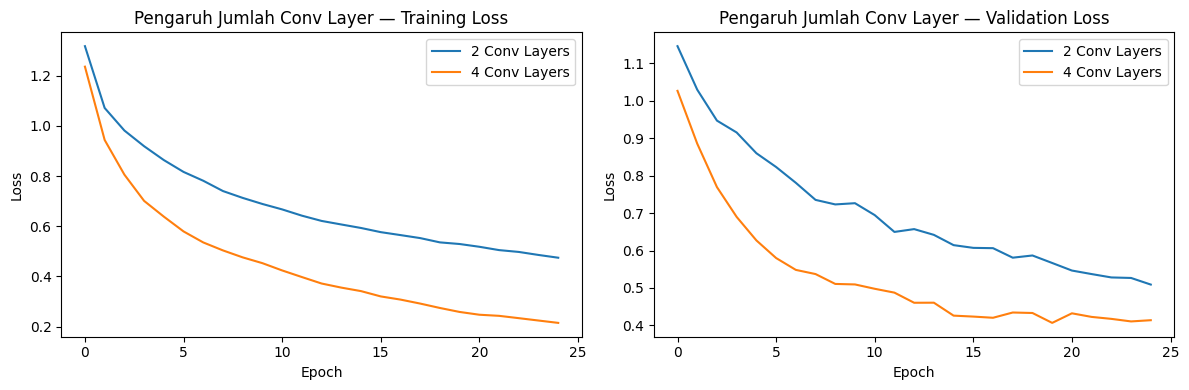

Mean val F1 — 2 conv: 0.8209,  4 conv: 0.8745


In [ ]:
def load_history(name):
    with open(os.path.join(HISTORY_DIR, f'{name}.json')) as f:
        return json.load(f)

def plot_loss_comparison(group_a, group_b, label_a, label_b, title, fname):
    def mean_curve(names, key):
        curves = [load_history(n)[key] for n in names]
        max_len = max(len(c) for c in curves)
        padded  = [c + [c[-1]] * (max_len - len(c)) for c in curves]
        return np.mean(padded, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, loss_key, title_suffix in [
        (axes[0], 'loss', 'Training Loss'),
        (axes[1], 'val_loss', 'Validation Loss'),
    ]:
        curve_a = mean_curve(group_a, loss_key)
        curve_b = mean_curve(group_b, loss_key)
        ax.plot(curve_a, label=label_a)
        ax.plot(curve_b, label=label_b)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'{title} — {title_suffix}')
        ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join('/kaggle/working/', fname), dpi=150)
    plt.show()

def get_names_by(key, value):
    return [r['name'] for r in summary if r[key] == value]

# Jumlah layer
names_2conv = get_names_by('n_conv', 2)
names_4conv = get_names_by('n_conv', 4)
plot_loss_comparison(names_2conv, names_4conv, '2 Conv Layers', '4 Conv Layers',
                     'Pengaruh Jumlah Conv Layer', 'loss_n_conv.png')

f1_2 = np.mean([r['val_f1'] for r in summary if r['n_conv'] == 2])
f1_4 = np.mean([r['val_f1'] for r in summary if r['n_conv'] == 4])
print(f'Mean val F1 — 2 conv: {f1_2:.4f},  4 conv: {f1_4:.4f}')

### 3b. Pengaruh Banyak Filter

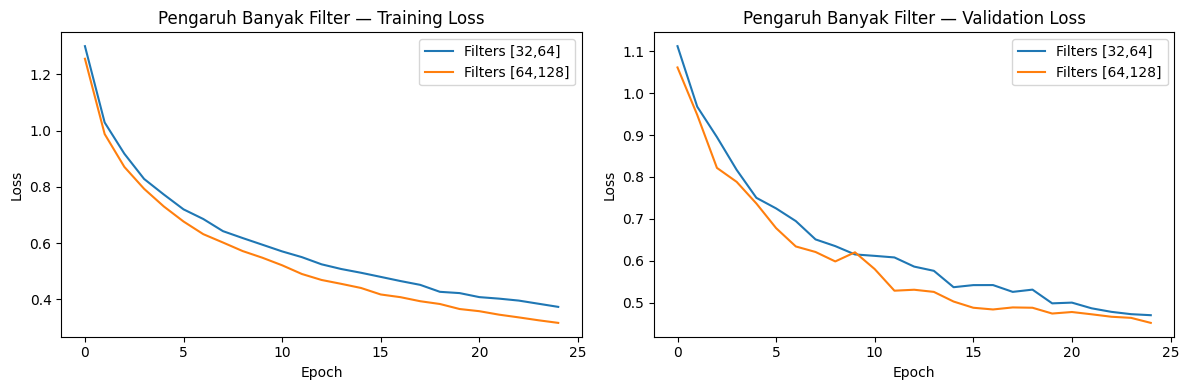

Mean val F1 — [32,64]: 0.8425,  [64,128]: 0.8529


In [20]:
names_small_f = [r['name'] for r in summary if r['filters'] == [32, 64]]
names_large_f = [r['name'] for r in summary if r['filters'] == [64, 128]]
plot_loss_comparison(names_small_f, names_large_f, 'Filters [32,64]', 'Filters [64,128]',
                     'Pengaruh Banyak Filter', 'loss_filters.png')

f1_s = np.mean([r['val_f1'] for r in summary if r['filters'] == [32, 64]])
f1_l = np.mean([r['val_f1'] for r in summary if r['filters'] == [64, 128]])
print(f'Mean val F1 — [32,64]: {f1_s:.4f},  [64,128]: {f1_l:.4f}')

### 3c. Pengaruh Ukuran Filter

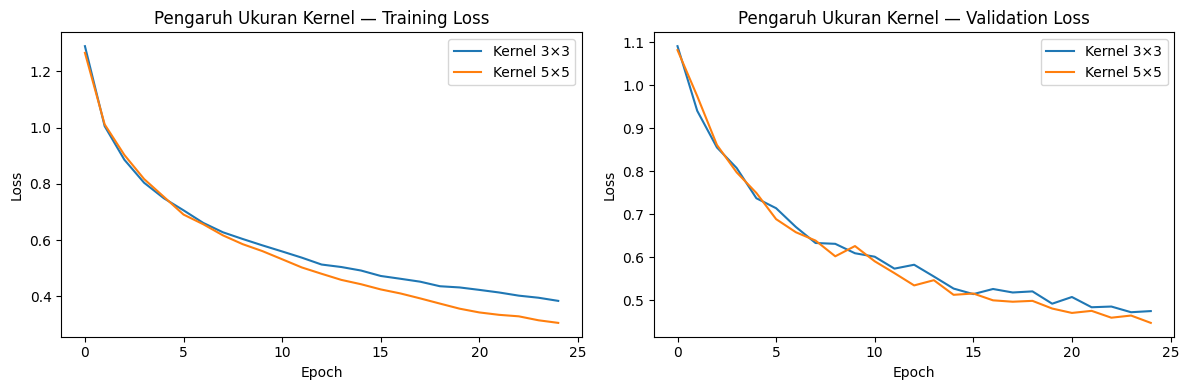

Mean val F1 — kernel 3: 0.8395,  kernel 5: 0.8560


In [21]:
names_k3 = get_names_by('kernel_size', 3)
names_k5 = get_names_by('kernel_size', 5)
plot_loss_comparison(names_k3, names_k5, 'Kernel 3×3', 'Kernel 5×5',
                     'Pengaruh Ukuran Kernel', 'loss_kernel.png')

f1_k3 = np.mean([r['val_f1'] for r in summary if r['kernel_size'] == 3])
f1_k5 = np.mean([r['val_f1'] for r in summary if r['kernel_size'] == 5])
print(f'Mean val F1 — kernel 3: {f1_k3:.4f},  kernel 5: {f1_k5:.4f}')

### 3d. Pengaruh Jenis Pooling

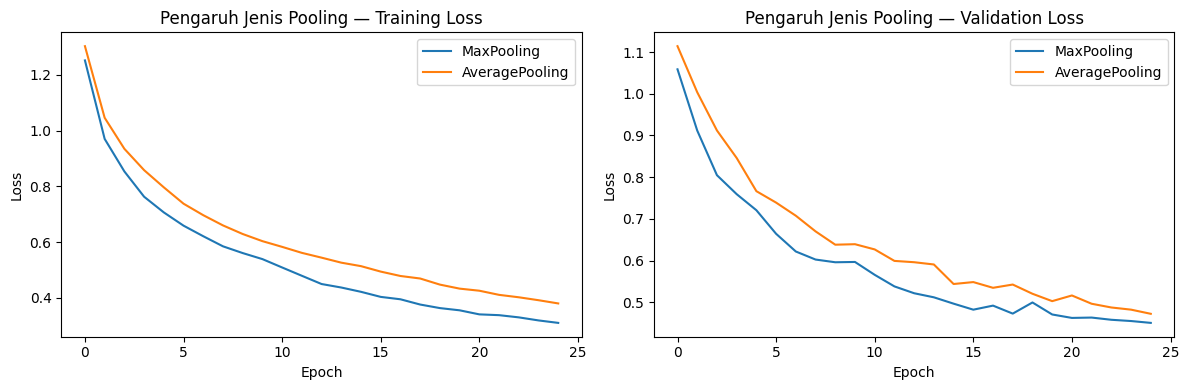

Mean val F1 — max: 0.8549,  avg: 0.8406


In [22]:
names_max = get_names_by('pooling', 'max')
names_avg = get_names_by('pooling', 'avg')
plot_loss_comparison(names_max, names_avg, 'MaxPooling', 'AveragePooling',
                     'Pengaruh Jenis Pooling', 'loss_pooling.png')

f1_max = np.mean([r['val_f1'] for r in summary if r['pooling'] == 'max'])
f1_avg = np.mean([r['val_f1'] for r in summary if r['pooling'] == 'avg'])
print(f'Mean val F1 — max: {f1_max:.4f},  avg: {f1_avg:.4f}')

### 3e. Shared vs Non Shared

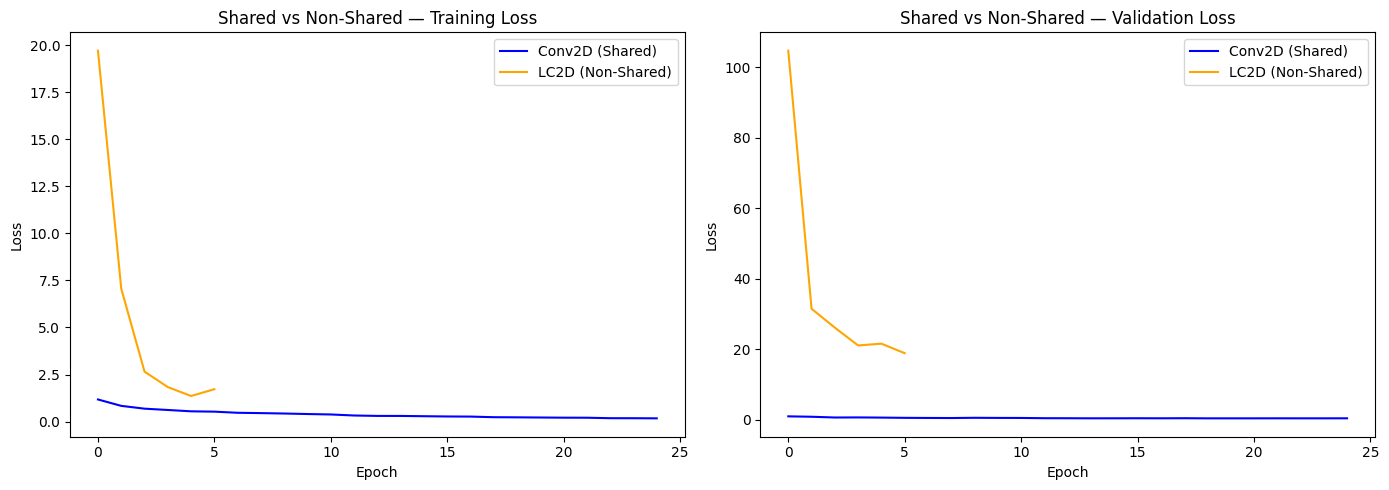

Conv2D — 25 epochs, final loss: 0.1725
LC2D   — 6 epochs,  final loss: 1.7206


In [4]:
HISTORY_DIR = '/kaggle/input/datasets/fudhailfayyadh0/datasetlokal2/data/histories'
best_name   = 'cnn_nL4_f64_128_k3_pMax'

lc_hist = {
    'loss':         [19.7073, 7.0633, 2.6538, 1.8335, 1.3601, 1.7206],
    'accuracy':     [0.8824,  0.6803, 0.7313, 0.7422, 0.7723, 0.7352],
    'val_loss':     [104.6760, 31.4542, 26.0994, 21.0461, 21.5508, 18.8471],
    'val_accuracy': [0.1670,  0.1670, 0.1670, 0.1670, 0.1670, 0.1670],
}

with open('/kaggle/working/lc2d_history.json', 'w') as f:
    json.dump(lc_hist, f)


with open(os.path.join(HISTORY_DIR, f'{best_name}.json')) as f:
    conv_hist = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(conv_hist['loss'], label='Conv2D (Shared)', color='blue')
axes[0].plot(lc_hist['loss'],   label='LC2D (Non-Shared)', color='orange')
axes[0].set_title('Shared vs Non-Shared — Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(conv_hist['val_loss'], label='Conv2D (Shared)', color='blue')
axes[1].plot(lc_hist['val_loss'],   label='LC2D (Non-Shared)', color='orange')
axes[1].set_title('Shared vs Non-Shared — Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/shared_vs_nonshared_loss.png', dpi=150)
plt.show()

print(f"Conv2D — {len(conv_hist['loss'])} epochs, final loss: {conv_hist['loss'][-1]:.4f}")
print(f"LC2D   — {len(lc_hist['loss'])} epochs,  final loss: {lc_hist['loss'][-1]:.4f}")


## 4. Tabel Hasil Semua 16 Arsitektur

In [23]:
print(f'{"#":<3} {"Model":<45} {"Val F1":>10}')
print('-' * 62)
for i, r in enumerate(sorted(summary, key=lambda x: -x['val_f1'])):
    marker = ' ← BEST' if r['name'] == best_info['name'] else ''
    print(f'{i+1:<3} {r["name"]:<45} {r["val_f1"]:>10.4f}{marker}')

#   Model                                             Val F1
--------------------------------------------------------------
1   cnn_nL4_f64_128_k3_pMax                           0.8869 ← BEST
2   cnn_nL4_f64_128_k5_pAvg                           0.8822
3   cnn_nL4_f32_64_k5_pMax                            0.8795
4   cnn_nL4_f64_128_k5_pMax                           0.8743
5   cnn_nL4_f32_64_k3_pMax                            0.8737
6   cnn_nL4_f32_64_k5_pAvg                            0.8715
7   cnn_nL4_f64_128_k3_pAvg                           0.8696
8   cnn_nL4_f32_64_k3_pAvg                            0.8586
9   cnn_nL2_f64_128_k5_pMax                           0.8577
10  cnn_nL2_f32_64_k5_pMax                            0.8401
11  cnn_nL2_f64_128_k5_pAvg                           0.8275
12  cnn_nL2_f32_64_k5_pAvg                            0.8151
13  cnn_nL2_f64_128_k3_pMax                           0.8147
14  cnn_nL2_f32_64_k3_pMax                            0.8118
15  cnn_nL2_f64

## 5. Kesimpulan dan Analisis

**Tuliskan kesimpulan di sini berdasarkan hasil eksperimen:**

### Pengaruh Jumlah Layer Konvolusi
- Penambahan jumlah layer konvolusi dari 2 menjadi 4 secara signifikan meningkatkan performa model. Model dengan 4 Conv Layers mencapai macro F1 sebesar 0.8745, lebih tinggi dibandingkan 2 Conv Layers yang hanya mencapai 0.8209.
- Model dengan 4 layer konvergen lebih cepat dan mencapai training loss yang jauh lebih rendah, menunjukkan kapasitas representasi yang lebih besar untuk menangkap fitur hierarkis gambar.
- Validation loss keduanya turun stabil tanpa overfitting yang berarti, mengindikasikan 4 layer masih berada dalam kapasitas yang sesuai untuk dataset ini.

### Pengaruh Banyak Filter
- Penggunaan filter yang lebih banyak ([64,128] vs [32,64]) memberikan peningkatan F1 dari 0.8425 menjadi 0.8529, menunjukkan bahwa kapasitas channel yang lebih besar membantu model belajar representasi fitur yang lebih beragam.
- Perbedaan antara kedua konfigurasi relatif kecil (~1%), mengindikasikan bahwa pada ukuran dataset ini, penambahan filter memberikan diminishing returns dan peningkatan jumlah layer lebih berpengaruh dibandingkan peningkatan jumlah filter.


### Pengaruh Ukuran Filter
- Kernel 5×5 mencapai macro F1 0.8560 dibandingkan kernel 3×3 sebesar 0.8395. Kernel yang lebih besar menangkap receptive field yang lebih luas sehingga lebih efektif untuk fitur skala besar pada gambar lanskap (misalnya tekstur langit, pegunungan).
- Kurva loss kedua konfigurasi hampir identik di awal pelatihan dan mulai diverge setelah epoch ke-15, menunjukkan perbedaan efek kernel baru terasa setelah model mulai mengoptimasi fitur-fitur yang lebih kompleks.

### Pengaruh Jenis Pooling
- MaxPooling unggul dengan macro F1 0.8549 dibandingkan AveragePooling 0.8406. Hal ini konsisten dengan literatur: MaxPooling lebih efektif untuk task klasifikasi karena mempertahankan fitur yang paling dominan/aktif di setiap region, sementara AveragePooling menghaluskan semua aktivasi sehingga sinyal fitur penting dapat terdilusi.
- Training loss MaxPooling lebih rendah (~0.28 vs ~0.38 di epoch akhir), mengindikasikan MaxPooling memberikan gradien yang lebih informatif selama pelatihan.

### Shared vs Non-Shared Parameter
- Conv2D (shared) hanya memiliki 257,862 parameter, sedangkan LC2D (non-shared) memiliki 524,077,190 parameter. Perbedaan ini terjadi karena Conv2D menggunakan kernel yang sama di seluruh posisi spasial, sementara LC2D mengalokasikan kernel unik untuk setiap posisi output sehingga jumlah parameter tumbuh sebanding dengan H_out × W_out.
- Dari sisi training, Conv2D menunjukkan kurva loss yang stabil dan konvergen sedangkan LC2D mengalami overfitting berat: training loss turun dari ~19.7 ke ~1.7 dalam 6 epoch namun validation loss tetap sangat tinggi dan val_accuracy stagnan di 0.1670 sepanjang pelatihan.
- Dari sisi performa akhir, Conv2D mencapai macro F1 0.8783 sementara LC2D hanya 0.0477. Ketidakmampuan LC2D untuk generalisasi disebabkan oleh jumlah parameter yang masif (membutuhkan ~1.95 GB hanya untuk bobot) sehingga model mudah overfit, berbeda dengan Conv2D yang justru lebih efisien karena weight sharing memaksa model belajar fitur yang berlaku umum di seluruh posisi spasial.

### From-Scratch vs Keras
- Persentase prediksi identik: **99.17%** (2,975 dari 3,000 sampel menghasilkan prediksi yang sama persis).
- Macro F1 Keras: **0.8783**, Macro F1 Scratch: **0.8784** — selisih hanya 0.0001, tidak signifikan secara praktis.
- Perbedaan kecil pada 0.83% sampel disebabkan akumulasi error presisi floating-point pada operasi NumPy sekuensial (CPU float32) dibandingkan operasi GPU Keras, namun error ini tidak mengubah keputusan klasifikasi akhir secara bermakna.
- Hasil ini memverifikasi bahwa implementasi forward propagation from scratch telah benar dan konsisten dengan model Keras yang terlatih.